In [3]:
import struct
import numpy as np

In [4]:
def read_idx1(filename):
    with open(filename, 'rb') as f:
        magic, num_items = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [5]:
def read_idx3(filename):
    with open(filename, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(
            f.read(), dtype=np.uint8
        ).reshape(num_images, rows, cols)
    return images

In [6]:
def filter_num(x, labels, images):
    num_images = []
    for i in range(0,60000):
        if (labels[i] == x):
            num_images.append(images[i])  

    return np.array(num_images)

In [7]:
def resize_images(images):
    new_images = []
    for i in range(0,len(images)):
        new_images.append(np.reshape(images[i],784))
    return np.array(new_images)/255

In [8]:
def mean_mle(samples):
    return sum(samples)/len(samples)

In [9]:
def cov_matrix_mle(samples,mean):
    var = []
    for i in range(0,len(samples)):
        y = np.reshape((samples[i]-mean),(784,1)) @ np.reshape((samples[i]-mean),(1,784))
        var.append(y)
    return np.array(sum(var))/len(samples)

In [10]:
def compute_params_qda(mean,variance,prior):
    quadratic_term = (-0.5)*(np.linalg.inv(variance + 0.0001 * np.eye(784)))
    linear_term = mean @ (np.linalg.inv(variance + 0.0001 * np.eye(784)))
    constant_term =  (-0.5) * (mean @ (np.linalg.inv(variance + 0.0001 * np.eye(784))) @ mean + np.log(np.linalg.det(variance) if np.linalg.det(variance) > 0 else 1)) + np.log(prior)
    return (quadratic_term,linear_term,constant_term)

In [11]:
def compute_params_lda(mean,variance,prior):
    linear_term = mean @ (np.linalg.inv(variance + 0.0001 * np.eye(784)))
    constant_term =  (-0.5) * (mean @ (np.linalg.inv(variance + 0.0001 * np.eye(784))) @ mean) + np.log(prior)
    return (linear_term,constant_term)

In [12]:
def linear_discriminant(point,params):
    return params[0] @ point + params[1]  

In [13]:
def quadratic_discriminant(point,params):
    return point @ params[0] @ point + params[1] @ point + params[2]

In [14]:
#read MNIST images and labels
labels = read_idx1(r"C:\Users\Mayank\Downloads\SML_A1_DATASET\train-labels.idx1-ubyte")
images = read_idx3(r"C:\Users\Mayank\Downloads\SML_A1_DATASET\train-images.idx3-ubyte")

#conversion to feature columns
images = resize_images(images)

train = {}
test = {}
mle = {}

for i in range(3):
    #filter for class 0,1,2 in corresponding iteration
    class_data = filter_num(i,labels,images)

    #random permutation of number
    np.random.seed(42)
    random_data = np.random.permutation(len(class_data))

    #apply this to data and select 0-99 & 100-199 for train and test, these are random since permutation was random
    train[i] = class_data[random_data[:100]]
    test[i] = class_data[random_data[100:200]]

    #compute mle estimates using train data
    mean = mean_mle(train[i])
    cov = cov_matrix_mle(train[i], mean)
    mle[i] = (mean,cov)

In [15]:
def classify(test,mle):
    cl = 0
    cq = 0
    params = {}
    for i in range(3):
        params[i] = {}
        params[i]["qda"] = compute_params_qda(mle[i][0], mle[i][1], 1)
        params[i]["lda"] = compute_params_lda(mle[i][0], (mle[0][1] + mle[1][1] + mle[2][1])/3,1)

    num = 0
    for i in range(3):
        for j in test[i]:
            #linear discriminant
            linear = [0,0,0]
            quadratic = [0,0,0]
            for k in range(3):
                linear[k] = linear_discriminant(j,params[k]["lda"])
                quadratic[k] = quadratic_discriminant(j,params[k]["qda"])

            l_pred = 0
            q_pred = 0
            for l in range(3):
                if (linear[l] == max(linear)):
                    l_pred = l
                if (quadratic[l] == max(quadratic)):
                    q_pred = l

            if (l_pred == i):
                cl+=1
            if (q_pred == i):
                cq+=1

            num+=1
            print(f"Test #{num} Actual = {i}\n")
            print(f"Linear Discriminant\nClass Zero:{linear[0]}\tOne:{linear[1]}\tTwo:{linear[2]}\nLDA Prediction = {l_pred}\n")
            print(f"Quadratic Discriminant\nClass Zero:{quadratic[0]}\tOne:{quadratic[1]}\tTwo:{quadratic[2]}\nLDA Prediction = {q_pred}\n")

    print(f"\nAccuracy\nLDA Accuracy = {cl/300}\nQDA Accuracy = {cq/300}")

In [16]:
classify(test,mle)

Test #1 Actual = 0

Linear Discriminant
Class Zero:691.413777395644	One:475.4655552983886	Two:166.73656947823838
LDA Prediction = 0

Quadratic Discriminant
Class Zero:-27514.960573391603	One:-239938.2884861229	Two:-98585.96139488263
LDA Prediction = 0

Test #2 Actual = 0

Linear Discriminant
Class Zero:27.975363526066758	One:-609.691888655664	Two:164.18914146643874
LDA Prediction = 2

Quadratic Discriminant
Class Zero:-30755.864470650213	One:-274722.8845156562	Two:-122257.84107882806
LDA Prediction = 0

Test #3 Actual = 0

Linear Discriminant
Class Zero:27.79273382421934	One:-463.5832509411297	Two:-470.6826994781169
LDA Prediction = 0

Quadratic Discriminant
Class Zero:-37218.13278228874	One:-84404.47502096943	Two:-83046.23523792691
LDA Prediction = 0

Test #4 Actual = 0

Linear Discriminant
Class Zero:1107.074047696612	One:551.0321443130961	Two:-737.1804890159251
LDA Prediction = 0

Quadratic Discriminant
Class Zero:-37206.225754883904	One:-329845.2756323409	Two:-166318.8532218898
LDA

In [17]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

C:\Users\Mayank\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Mayank\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Mayank\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Mayank\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Mayank\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

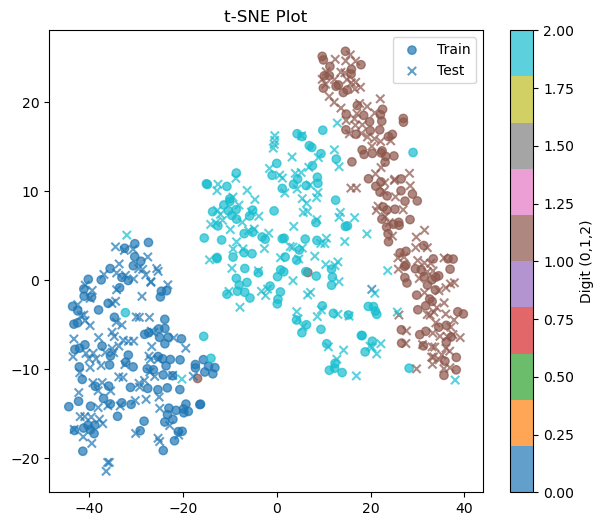

In [18]:
X_train = np.vstack([train[0], train[1], train[2]])
X_test  = np.vstack([test[0],  test[1],  test[2]])

y_train = np.array(
    [0]*len(train[0]) +
    [1]*len(train[1]) +
    [2]*len(train[2])
)

y_test = np.array(
    [0]*len(test[0]) +
    [1]*len(test[1]) +
    [2]*len(test[2])
)
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

split = len(X_train)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_embedded = tsne.fit_transform(X_all)

X_train_2d = X_embedded[:split]
X_test_2d  = X_embedded[split:]

plt.figure(figsize=(7, 6))

plt.scatter(
    X_train_2d[:,0], X_train_2d[:,1],
    c=y_train, cmap="tab10",
    marker="o", alpha=0.7, label="Train"
)

plt.scatter(
    X_test_2d[:,0], X_test_2d[:,1],
    c=y_test, cmap="tab10",
    marker="x", alpha=0.7, label="Test"
)

plt.colorbar(label="Digit (0,1,2)")
plt.legend()
plt.title("t-SNE Plot")
plt.show()
